In [6]:
!pip install control
!pip install matplotlib

In [2]:
import control as clt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Define pendulum constants
m = 0.2 # mass of pendulum
M = 0.5 # mass of cart
l = 0.3 # length of pendulum 
I = m*pow((2*l),2)/12 # Moment of inertia (COM) [m*(2l)ˆ2]/12
J = I + m*l*l # 0.006 + 0.2*0.3*0.3 Icom + mlˆ2 (Parallel axis theorm)
g = 9.8
print(I, J)

0.005999999999999999 0.023999999999999997


In [4]:
"""
    (M+m)x'' + mL*Cos(phi).phi'' = u + ML*Sin(phi).(phi')ˆ2        
    mL*Cos(phi)x'' + (I+mlˆ2)*phi'' = mgLSin(phi)

    We calculate [x'' phi'']

    Discrete LTI equation
    X[k+1] = Ad*x[k] + Bd*u[k]
    
"""
D_denom = (M+m)*J - (m*m*l*l)
A = np.array([
    [0, 1, 0, 0],
    [0, 0, -1*(m*m*g*l*l)/D_denom, 0],
    [0, 0, 0, 1],
    [0, 0, (M+m)*m*g*l/D_denom, 0]
])

B = np.array([
    [0],
    [(J)/D_denom],
    [0],
    [-1*m*l/D_denom]
])
C = np.eye(4)
D = np.zeros((4,1))
Q = np.diag([1, 1, 100, 100])
R = np.array([[100]])
I = np.eye(4)

In [5]:
def get_discrete_system(A, B, C, D, t=0.30):
    sys_c =clt.ss(A, B, C, D)
    return clt.c2d(sys_c, t, method='zoh')

In [6]:
"""
    Todo Bryson & Ho – Applied Optimal Control (1975)
"""

Q_R_modes = [
    {
        "label": "Base line",
        "Q": np.diag([1, 1, 1, 1]),
        "R": np.array([1])
    },
    {
        "label": "Angle priority",
        "Q": np.diag([1, 1, 100, 10]),
        "R": np.array([[1]])
    },
    {
        "label": "Position priority",
        "Q": np.diag([100, 10, 1, 1]),
        "R": np.array([[2]])
    },
    {
        "label": "Aggresive control",
        "Q": np.diag([100, 10, 100, 10]),
        "R": np.array([[0.1]])
    },
    {
        "label": "Energy saving",
        "Q": np.diag([1, 1, 10, 1]),
        "R": np.array([[10]])
    },
]

,mode,sampling_ms,max_misses,K0,K1,K2,K3
1,Base line,10.0,14,-0.930854,-1.808353,-19.512766,-3.754417
20,Angle priority,10.0,9,-0.900188,-1.999290,-24.206859,-5.088978
39,Position priority,10.0,11,-6.480725,-6.055948,-31.413609,-6.083726
58,Aggresive control,10.0,3,-23.770885,-21.232774,-88.144034,-18.446548
77,Energy saving,10.0,17,-0.297297,-0.805057,-16.085387,-2.955555


,mode,sampling_ms,max_misses,K0,K1,K2,K3
3,Base line,20.0,7,-0.866502,-1.688026,-18.727439,-3.592953
22,Angle priority,20.0,4,-0.810634,-1.805052,-22.582644,-4.706967
41,Position priority,20.0,5,-5.939789,-5.582909,-29.662112,-5.733558
60,Aggresive control,20.0,1,-18.100118,-16.293060,-69.856361,-14.513057
79,Energy saving,20.0,8,-0.279500,-0.758348,-15.572568,-2.859073


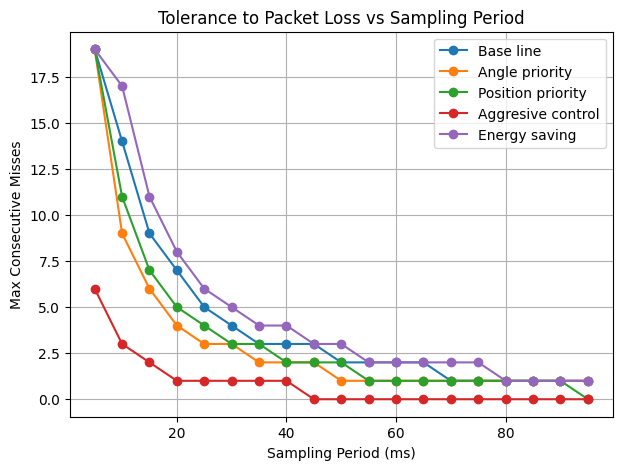

In [8]:
sampling_periods = np.arange(0.005, 0.100, 0.005)
plt.figure(figsize=(7,5))

records = []

for mode in Q_R_modes:
    Q = mode.get("Q")
    R = mode.get("R")
    max_misses_list = []
    for h in sampling_periods:
        system = get_discrete_system(A, B, C, D, t=h)
        K, _, _ = clt.dlqr(system.A, system.B, Q, R)
        
        A_d = system.A
        B_d = system.B

        # closed_loop = Ad - Bd @ K
        # eigs = np.linalg.eigvals(closed_loop)
        
        n = A.shape[0]
        I = np.eye(n)
        Z = np.zeros((1,1))
        
        A_hit = np.block([
            [A_d - K*B_d, np.zeros((n, 1))],
            [-K, Z]
        ])
        A_miss = np.block([
            [A_d, B_d],
            [np.zeros((1, n)), np.eye(1)]
        ])
        
        miss = 0
        for i in range(1, 20):
            Phi = np.linalg.matrix_power(A_miss, i)@A_hit
            Rho = max(abs(np.linalg.eigvals(Phi)))
            if Rho > 1:
                break
            miss = i
        max_misses_list.append(miss)
        
        records.append({
                "mode": mode["label"],
                "sampling_ms": round(h * 1000, 3),
                "max_misses": miss,
                **{f"K{i}": v for i, v in enumerate(K.flatten())}
            })


    plt.plot(sampling_periods*1000, max_misses_list, marker='o', label=mode.get("label"))


df = pd.DataFrame(records)
filtered_df = df[df["sampling_ms"] == 10]
display(filtered_df)
filtered_df = df[df["sampling_ms"] == 20]
display(filtered_df)

plt.xlabel("Sampling Period (ms)")
plt.ylabel("Max Consecutive Misses")
plt.title("Tolerance to Packet Loss vs Sampling Period")

plt.legend()
plt.grid(True)

plt.show()